<a href="https://colab.research.google.com/github/MariethDataSc/ClassActivities_Mastery/blob/main/Actividad3_CNN_CIFAR10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividad 3: Diseño y Regularización de Redes Neuronales Convolucionales (CNN)

**Dataset:** CIFAR-10 (imágenes a color, 10 clases)
**Curso:** Deep Learning — Unidad 3: Redes Neuronales Convolucionales (CNN) y Técnicas de Regularización

**Integrantes del equipo:**
- Madelayne Marieth Loor Vera
- Mauricio Palomino Palacios



## Carga y Preparación del Dataset

**Dataset seleccionado:** CIFAR-10, disponible en `keras.datasets`. Contiene 60,000 imágenes
a color de 32x32 píxeles (3 canales RGB), distribuidas en 10 clases balanceadas (avión,
automóvil, pájaro, gato, ciervo, perro, rana, caballo, barco, camión).

**Preprocesamiento:**
- Normalización de píxeles al rango [0, 1] (dividiendo entre 255)
- Codificación one-hot de las etiquetas para clasificación multiclase (10 clases → Softmax).


In [ ]:
# Importación de librerías
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1862s 11us/step
X_train: (50000, 32, 32, 3) | y_train: (50000, 1)
X_test: (10000, 32, 32, 3) | y_test: (10000, 1)


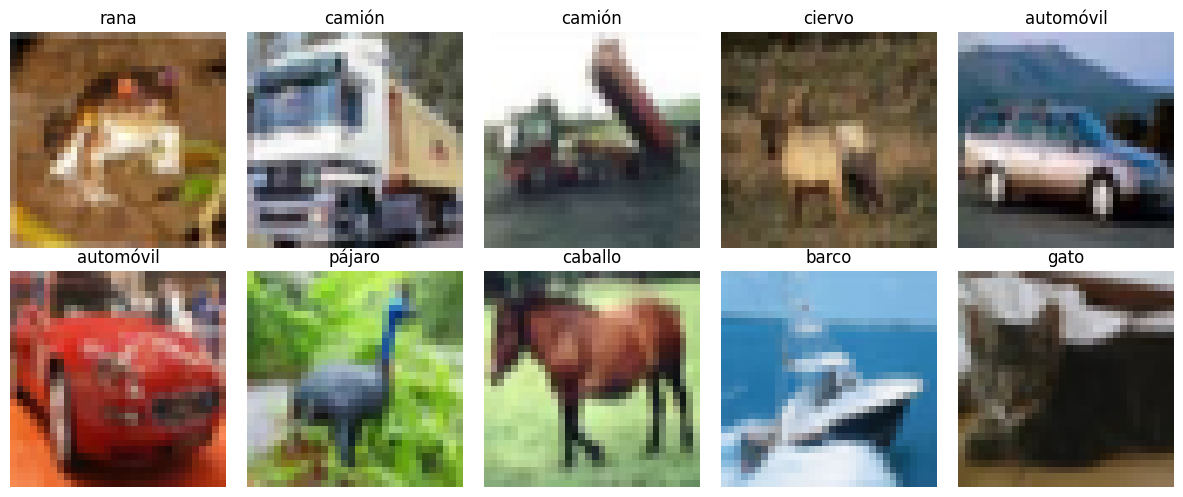

In [ ]:
# Carga del dataset CIFAR-10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

clases = ['avión', 'automóvil', 'pájaro', 'gato', 'ciervo',
          'perro', 'rana', 'caballo', 'barco', 'camión']

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_test:", X_test.shape, "| y_test:", y_test.shape)

# Visualizar algunas imágenes de ejemplo
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i])
    ax.set_title(clases[y_train[i][0]])
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# Normalización: escalar píxeles de [0, 255] a [0, 1]
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

# One-hot encoding de las etiquetas (10 clases)
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

print("Rango de píxeles tras normalizar: [{:.1f}, {:.1f}]".format(
    X_train_norm.min(), X_train_norm.max()))
print("Forma de etiquetas one-hot:", y_train_cat.shape)

Rango de píxeles tras normalizar: [0.0, 1.0]
Forma de etiquetas one-hot: (50000, 10)


## Arquitectura Base de la CNN (sin regularización)

### Diseño de la arquitectura

Siguiendo el patrón visto en clases (`Convolution → MaxPooling → Convolution → MaxPooling
→ Flatten → Fully Connected`), se propone:

| Etapa | Capa | Configuración | Justificación |
|---|---|---|---|
| Extracción | Conv2D #1 | 32 filtros, kernel 3x3, ReLU | Detecta bordes y patrones simples de bajo nivel |
| Extracción | MaxPooling #1 | 2x2 | Reduce dimensionalidad |
| Extracción | Conv2D #2 | 64 filtros, kernel 3x3, ReLU | Combina features de bajo nivel en patrones más complejos |
| Extracción | MaxPooling #2 | 2x2 | Reduce dimensionalidad nuevamente |
| Extracción | Conv2D #3 | 64 filtros, kernel 3x3, ReLU | Extrae features de alto nivel (formas, texturas complejas) |
| Transición | Flatten | — | Convierte el mapa de características 2D en vector 1D |
| Clasificación | Dense #1 | 64 neuronas, ReLU | Combina las características extraídas para la decisión final |
| Clasificación | Dense (salida) | 10 neuronas, Softmax | Clasificación multiclase (10 categorías de CIFAR-10) |

**Por qué esta arquitectura:**
- El número de filtros **aumenta progresivamente** (32 → 64 → 64) siguiendo el patrón estándar
  de CNN: las primeras capas detectan patrones simples con pocos filtros, las capas más
  profundas combinan esos patrones en representaciones más abstractas y necesitan más filtros.
- Se usa **kernel 3x3** en todas las capas convolucionales, replicando VGG : apilar filtros pequeños (3x3) logra el mismo efecto receptivo que un filtro
  grande (5x5, 7x7) con menor costo computacional.
- **MaxPooling 2x2** después de cada bloque convolucional reduce las dimensiones espaciales a
  la mitad, disminuyendo parámetros y aportando cierta invariancia a pequeñas traslaciones.
- La capa de salida usa **Softmax** (no Sigmoide) porque el problema es de clasificación
  **multiclase** (10 categorías).


In [ ]:
def crear_cnn_base():
    """CNN base SIN regularización (Dropout / L2), para usar como línea base comparativa."""
    keras.backend.clear_session()
    tf.random.set_seed(SEED)

    model = keras.Sequential([
        layers.Input(shape=(32, 32, 3)),

        # --- Etapa de Extracción de Características ---
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', name='conv_1'),
        layers.MaxPooling2D((2, 2), name='pool_1'),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv_2'),
        layers.MaxPooling2D((2, 2), name='pool_2'),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='conv_3'),

        # --- Transición ---
        layers.Flatten(name='flatten'),

        # --- Etapa de Clasificación ---
        layers.Dense(64, activation='relu', name='dense_1'),
        layers.Dense(10, activation='softmax', name='salida')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

modelo_base = crear_cnn_base()
modelo_base.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 319,178 (1.22 MB)

 Trainable params: 319,178 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

## Entrenamiento del Modelo Base

Se entrenó primero el modelo **sin regularización** para observar si efectivamente aparecen problemas de overfiftting (loss de entrenamiento bajando mientras el de
validación se estanca o sube).


In [ ]:
EPOCHS = 45
BATCH_SIZE = 64

history_base = modelo_base.fit(
    X_train_norm, y_train_cat,
    validation_data=(X_test_norm, y_test_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/45
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.4886 - loss: 1.4213 - val_accuracy: 0.5959 - val_loss: 1.1186
Epoch 2/45
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6336 - loss: 1.0384 - val_accuracy: 0.6603 - val_loss: 0.9528
Epoch 3/45
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6938 - loss: 0.8733 - val_accuracy: 0.6976 - val_loss: 0.8664
Epoch 4/45
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.7310 - loss: 0.7652 - val_accuracy: 0.7088 - val_loss: 0.8349
Epoch 5/45
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7630 - loss: 0.6778 - val_accuracy: 0.7132 - val_loss: 0.8338
Epoch 6/45
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7853 - loss: 0.6152 - val_accuracy: 0.7220 - val_loss: 0.8355
Epoch 7/45
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8095 - loss: 0.5512 - val_accuracy: 0.7210 - val_loss: 0.8855
Epoch 8/45
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8277 - loss: 0.4946 - val_accuracy: 

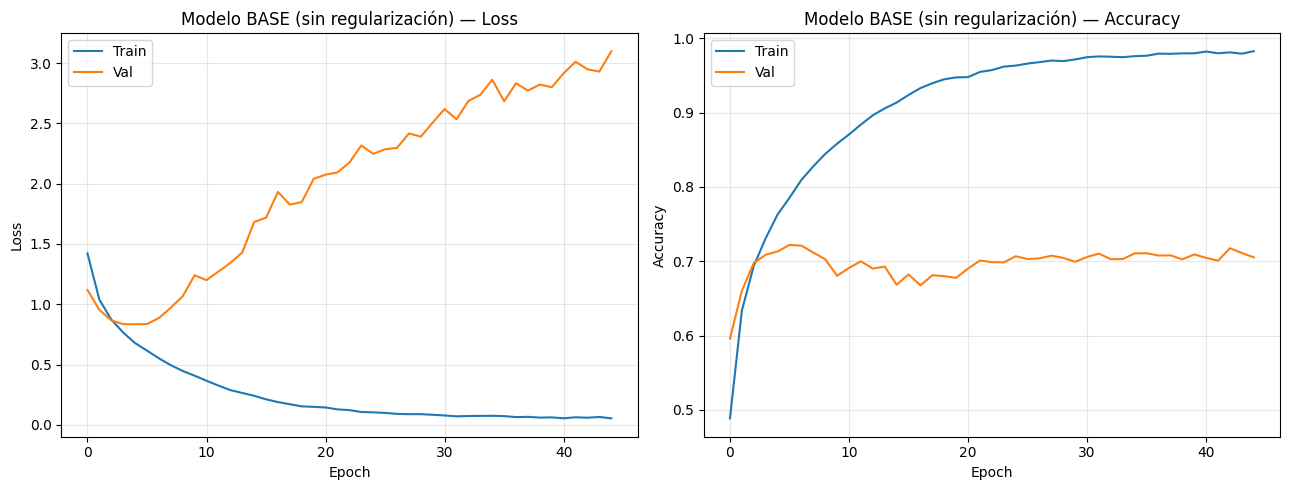


Resultado final -> Train accuracy: 0.9827 | Val accuracy: 0.7053
Brecha train-val (accuracy): 0.2774


In [ ]:
# Gráfico de diagnóstico: Loss y Accuracy del modelo base
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(history_base.history['loss'], label='Train')
axes[0].plot(history_base.history['val_loss'], label='Val')
axes[0].set_title('Modelo BASE (sin regularización) — Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history_base.history['accuracy'], label='Train')
axes[1].plot(history_base.history['val_accuracy'], label='Val')
axes[1].set_title('Modelo BASE (sin regularización) — Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('modelo_base_diagnostico.png', dpi=120)
plt.show()

print(f"\nResultado final -> Train accuracy: {history_base.history['accuracy'][-1]:.4f} | "
      f"Val accuracy: {history_base.history['val_accuracy'][-1]:.4f}")
print(f"Brecha train-val (accuracy): {history_base.history['accuracy'][-1] - history_base.history['val_accuracy'][-1]:.4f}")

### Diagnóstico esperado

Sí, se confirma el patrón de overfitting. A partir de la época ~10-12,
la curva de `val_loss` comienza a subir de forma sostenida (hasta 3.0988 en la época 45),
mientras que la `loss` de entrenamiento sigue bajando monótonamente hasta 0.0533. El modelo deja de generalizar y empieza a memorizar el set de
entrenamiento.

- **Accuracy final (train):** 0.9827
- **Accuracy final (val):** 0.7053
- **Brecha train-val:** 0.2774

Esta brecha es considerable y confirma que, con CIFAR-10 y una CNN con capacidad suficiente, el sobreajuste aparece de forma clara cuando no hay
ningún mecanismo de regularización. El modelo base "memoriza" el 98% de las imágenes de
entrenamiento, pero solo generaliza correctamente al 70% de los datos que nunca ha visto.


## Arquitectura CNN con Regularización (Dropout + L2)

### Técnicas aplicadas

**1. Dropout**: desactiva aleatoriamente una fracción de las neuronas
durante cada paso de entrenamiento, forzando a la red a no depender excesivamente de neuronas
específicas y mejorando su capacidad de generalización. Se aplica principalmente en las capas
densas.

**2. Regularización L2**: añade una penalización a la función de pérdida
proporcional al cuadrado de la magnitud de los pesos.

Esto evita que los pesos crezcan de forma descontrolada, produciendo un modelo más simple y
menos propenso a memorizar ruido del set de entrenamiento.


In [ ]:
def crear_cnn_regularizada(dropout_rate=0.3, l2_lambda=0.001):
    """CNN con Dropout y regularización L2 aplicadas."""
    keras.backend.clear_session()
    tf.random.set_seed(SEED)

    reg = regularizers.l2(l2_lambda)

    model = keras.Sequential([
        layers.Input(shape=(32, 32, 3)),

        # --- Etapa de Extracción de Características ---
        layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                      kernel_regularizer=reg, name='conv_1'),
        layers.MaxPooling2D((2, 2), name='pool_1'),
        layers.Dropout(dropout_rate * 0.5, name='dropout_conv_1'),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                      kernel_regularizer=reg, name='conv_2'),
        layers.MaxPooling2D((2, 2), name='pool_2'),
        layers.Dropout(dropout_rate * 0.5, name='dropout_conv_2'),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                      kernel_regularizer=reg, name='conv_3'),

        # --- Transición ---
        layers.Flatten(name='flatten'),

        # --- Etapa de Clasificación ---
        layers.Dense(64, activation='relu', kernel_regularizer=reg, name='dense_1'),
        layers.Dropout(dropout_rate, name='dropout_dense'),
        layers.Dense(10, activation='softmax', name='salida')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

modelo_regularizado = crear_cnn_regularizada(dropout_rate=0.3, l2_lambda=0.001)
modelo_regularizado.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_conv_1 (Dropout)        │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_conv_2 (Dropout)        │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_dense (Dropout)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ salida (Dense)                  │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 319,178 (1.22 MB)

 Trainable params: 319,178 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

## Entrenamiento del Modelo Regularizado y Comparación

Se entrena el modelo regularizado bajo las mismas condiciones (épocas, batch size, semilla) que
el modelo base. Se añade adicionalmente
**Early Stopping** para detener el
entrenamiento si el val_loss deja de mejorar.


In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

history_reg = modelo_regularizado.fit(
    X_train_norm, y_train_cat,
    validation_data=(X_test_norm, y_test_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/45
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.3674 - loss: 1.8250 - val_accuracy: 0.5082 - val_loss: 1.4887
Epoch 2/45
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.4931 - loss: 1.5222 - val_accuracy: 0.5760 - val_loss: 1.3293
Epoch 3/45
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5416 - loss: 1.4219 - val_accuracy: 0.6067 - val_loss: 1.2653
Epoch 4/45
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5794 - loss: 1.3414 - val_accuracy: 0.6448 - val_loss: 1.1696
Epoch 5/45
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6034 - loss: 1.2935 - val_accuracy: 0.6696 - val_loss: 1.1183
Epoch 6/45
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6215 - loss: 1.2502 - val_accuracy: 0.6847 - val_loss: 1.0968
Epoch 7/45
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6327 - loss: 1.2259 - val_accuracy: 0.6884 - val_loss: 1.0793
Epoch 8/45
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6469 - loss: 1.1989 - val_accuracy: 

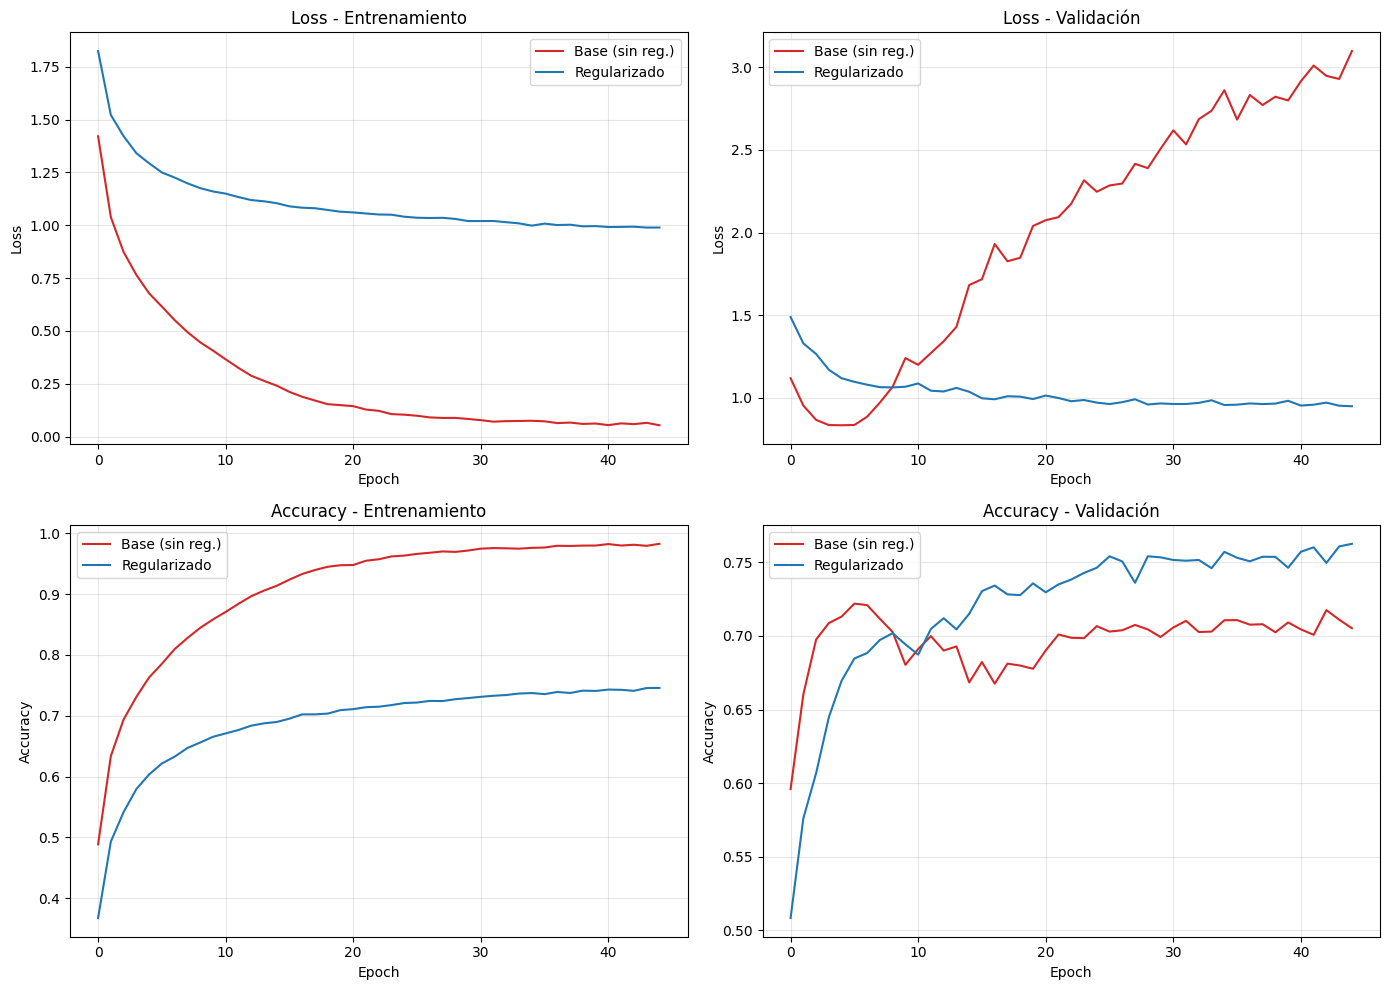

In [ ]:
# Gráfico comparativo: Modelo BASE vs. Modelo REGULARIZADO
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss - Train
axes[0, 0].plot(history_base.history['loss'], label='Base (sin reg.)', color='tab:red')
axes[0, 0].plot(history_reg.history['loss'], label='Regularizado', color='tab:blue')
axes[0, 0].set_title('Loss - Entrenamiento')
axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Loss'); axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3)

# Loss - Val
axes[0, 1].plot(history_base.history['val_loss'], label='Base (sin reg.)', color='tab:red')
axes[0, 1].plot(history_reg.history['val_loss'], label='Regularizado', color='tab:blue')
axes[0, 1].set_title('Loss - Validación')
axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Loss'); axes[0, 1].legend(); axes[0, 1].grid(alpha=0.3)

# Accuracy - Train
axes[1, 0].plot(history_base.history['accuracy'], label='Base (sin reg.)', color='tab:red')
axes[1, 0].plot(history_reg.history['accuracy'], label='Regularizado', color='tab:blue')
axes[1, 0].set_title('Accuracy - Entrenamiento')
axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('Accuracy'); axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)

# Accuracy - Val
axes[1, 1].plot(history_base.history['val_accuracy'], label='Base (sin reg.)', color='tab:red')
axes[1, 1].plot(history_reg.history['val_accuracy'], label='Regularizado', color='tab:blue')
axes[1, 1].set_title('Accuracy - Validación')
axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('Accuracy'); axes[1, 1].legend(); axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('comparacion_base_vs_regularizado.png', dpi=120)
plt.show()

In [ ]:
# Tabla resumen comparativa
import pandas as pd

resumen = pd.DataFrame({
    'Modelo Base (sin reg.)': {
        'Loss final (train)': history_base.history['loss'][-1],
        'Loss final (val)': history_base.history['val_loss'][-1],
        'Accuracy final (train)': history_base.history['accuracy'][-1],
        'Accuracy final (val)': history_base.history['val_accuracy'][-1],
        'Brecha train-val (accuracy)': history_base.history['accuracy'][-1] - history_base.history['val_accuracy'][-1],
    },
    'Modelo Regularizado': {
        'Loss final (train)': history_reg.history['loss'][-1],
        'Loss final (val)': history_reg.history['val_loss'][-1],
        'Accuracy final (train)': history_reg.history['accuracy'][-1],
        'Accuracy final (val)': history_reg.history['val_accuracy'][-1],
        'Brecha train-val (accuracy)': history_reg.history['accuracy'][-1] - history_reg.history['val_accuracy'][-1],
    }
}).T

resumen.round(4)

,Loss final (train),Loss final (val),Accuracy final (train),Accuracy final (val),Brecha train-val (accuracy)
Modelo Base (sin reg.),0.0533,3.0988,0.9827,0.7053,0.2774
Modelo Regularizado,0.9894,0.9490,0.7457,0.7627,-0.0170


### Conclusiones del análisis

El modelo regularizado con Dropout + L2 controló de forma efectiva el sobreajuste observado en el modelo base: la brecha train-val se redujo drásticamente de 0.2774 a -0.0170, incluso revirtiendo su signo, mientras que el accuracy de entrenamiento bajó de 0.98 a 0.74 esto es esperado y saludable, ya que el modelo dejó de memorizar tan fácilmente los datos y empezó a clasificar. El accuracy de validación mejoró de 0.7053 a 0.7627, evidenciando que la regularización no solo controla el overfitting sino que mejora la capacidad real de generalización; esto se confirma visualmente en la curva de Loss de Validación, donde el modelo base sube sostenidamente, mientras el modelo regularizado se estabiliza y se mantiene plano, demostrando el efecto protector directo de Dropout + L2.


## Pruebas de Hiperparámetros

Se prueban
distintas combinaciones de `dropout_rate` y `l2_lambda` para encontrar el mejor balance entre
capacidad de aprendizaje y control de sobreajuste. De ahí escogimos el que mejor resultados dio.


In [ ]:
configuraciones_reg = [
    {'nombre': 'Dropout bajo + L2 bajo',   'dropout_rate': 0.2, 'l2_lambda': 0.0001},
    {'nombre': 'Dropout medio + L2 medio', 'dropout_rate': 0.3, 'l2_lambda': 0.001},
    {'nombre': 'Dropout alto + L2 alto',   'dropout_rate': 0.5, 'l2_lambda': 0.01},
    {'nombre': 'Solo Dropout (sin L2)',    'dropout_rate': 0.3, 'l2_lambda': 0.0},
    {'nombre': 'Solo L2 (sin Dropout)',    'dropout_rate': 0.0, 'l2_lambda': 0.001},
]

resultados_tuning = {}

for config in configuraciones_reg:
    print(f"Entrenando: {config['nombre']}")
    modelo = crear_cnn_regularizada(
        dropout_rate=config['dropout_rate'],
        l2_lambda=config['l2_lambda']
    )
    es = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

    history = modelo.fit(
        X_train_norm, y_train_cat,
        validation_data=(X_test_norm, y_test_cat),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[es],
        verbose=0
    )

    resultados_tuning[config['nombre']] = {
        'val_loss': history.history['val_loss'][-1],
        'val_accuracy': history.history['val_accuracy'][-1],
        'brecha': history.history['accuracy'][-1] - history.history['val_accuracy'][-1],
        'history': history.history
    }
    print(f"  -> val_accuracy={resultados_tuning[config['nombre']]['val_accuracy']:.4f} | "
          f"brecha train-val={resultados_tuning[config['nombre']]['brecha']:.4f}\n")

Entrenando: Dropout bajo + L2 bajo
  -> val_accuracy=0.7374 | brecha train-val=0.0734

Entrenando: Dropout medio + L2 medio
  -> val_accuracy=0.7660 | brecha train-val=-0.0193

Entrenando: Dropout alto + L2 alto
  -> val_accuracy=0.5482 | brecha train-val=-0.0645

Entrenando: Solo Dropout (sin L2)
  -> val_accuracy=0.7400 | brecha train-val=0.0662

Entrenando: Solo L2 (sin Dropout)
  -> val_accuracy=0.7128 | brecha train-val=0.0975



In [ ]:
# Tabla comparativa de la sintonía de hiperparámetros
tabla_tuning = pd.DataFrame({
    nombre: {'val_loss': r['val_loss'], 'val_accuracy': r['val_accuracy'], 'brecha_train_val': r['brecha']}
    for nombre, r in resultados_tuning.items()
}).T.sort_values('val_accuracy', ascending=False)

print("Ranking de configuraciones (ordenado por mejor val_accuracy):")
tabla_tuning.round(4)

Ranking de configuraciones (ordenado por mejor val_accuracy):


,val_loss,val_accuracy,brecha_train_val
Dropout medio + L2 medio,0.9215,0.7660,-0.0193
Solo Dropout (sin L2),0.8566,0.7400,0.0662
Dropout bajo + L2 bajo,0.9619,0.7374,0.0734
Solo L2 (sin Dropout),1.1823,0.7128,0.0975
Dropout alto + L2 alto,1.4411,0.5482,-0.0645


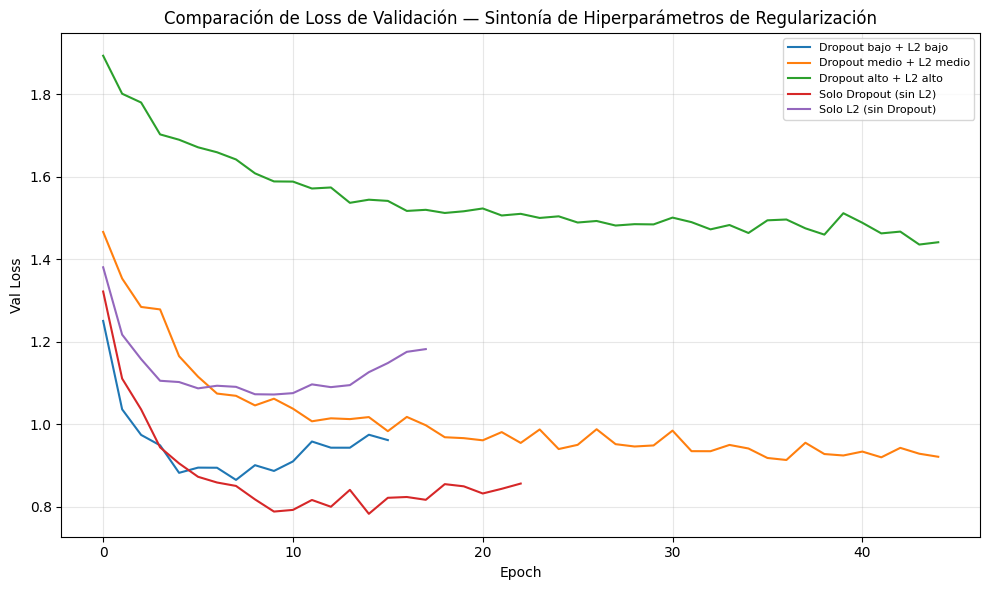

In [ ]:
# Gráfico comparativo de Val Loss para cada configuración probada
plt.figure(figsize=(10, 6))
for nombre, r in resultados_tuning.items():
    plt.plot(r['history']['val_loss'], label=nombre)
plt.title('Comparación de Loss de Validación — Sintonía de Hiperparámetros de Regularización')
plt.xlabel('Epoch'); plt.ylabel('Val Loss'); plt.legend(fontsize=8); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('tuning_regularizacion.png', dpi=120)
plt.show()

## Conclusión
Dropout medio + L2 medio** (dropout_rate=0.3, l2_lambda=0.001),
con val_accuracy=0.7660 y una brecha train-val de **-0.0193** (negativa: el modelo generaliza
incluso levemente mejor de lo que le va en entrenamiento, señal de una regularización bien
calibrada, no excesiva). Este resultado nos ayudó a seleccionar el parámetro correcto para entrenar al modelo (val_accuracy=0.7627, brecha=-0.0170), confirmando que la configuración
"medio + medio" es estable y reproducible.